In [1]:
import os, sys, glob
# from abc import ABCMeta, abstractmethod, abstractproperty
import abc
from enum import Enum
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
import json

import space_phot
from astropy.io import fits
from jwst.associations import asn_from_list
from jwst.associations.lib.rules_level3_base import DMS_Level3_Base
from jwst.pipeline import Image3Pipeline
from jwst.skymatch import SkyMatchStep
from jwst.datamodels import ModelLibrary

# Hack - I moved this into a local notebooks dir...
sys.path.append("/Users/dcoulter/Code/diffpype/src/jwst_diff")
from image1overf import sub1fimaging

sys.path.append("/Users/dcoulter/Code/diffpype/src/workflow_manager")
from data_repository import RepositoryFactory 
from data_utils import DataUtils
from visualization import Visualizer


from shapely.geometry import Point
from shapely.geometry.polygon import Polygon

from mocpy import MOC
from mocpy import WCS as mocWCS
from astropy.wcs import WCS
import matplotlib.pyplot as plt
from astropy.time import Time
import numpy as np

import pandas as pd
import mysql.connector

import mysql.connector
from mysql.connector import Error
from mysql.connector.pooling import MySQLConnectionPool
from pprint import pprint
import math

import pdb

import healpy as hp



/opt/homebrew/Caskroom/miniconda/base/envs/new_base/lib/python3.12/site-packages/stsci/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)



The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    


# Simulate data access layer

In [2]:
jwst_sw_linear_size = 1.054 # arcmin on a side
jwst_sw_module_area_sq_deg = (2040*0.031/3600)**2
print("\nArea per JWST SW module: %s deg^2" % jwst_sw_module_area_sq_deg)

JWST_MODULE_NSIDE = 2097152
power_of_two = int(np.log10(JWST_MODULE_NSIDE)/np.log10(2))
print("Max Depth: %s" % power_of_two)
jwst_hp_area_sq_deg = hp.nside2pixarea(nside=JWST_MODULE_NSIDE, degrees=True)
print("Area per JWST_MODULE_NSIDE %s pixel: %s deg^2" % (JWST_MODULE_NSIDE, jwst_hp_area_sq_deg))

hp_per_jwst = jwst_sw_module_area_sq_deg/jwst_hp_area_sq_deg
print("JWST_MODULE_NSIDE pixels per native JWST SW module: %s" % hp_per_jwst)


GLOBAL_CONFIG = {
    "mysql_config": {
        'host': '127.0.0.1',
        'port':'3307',
        'database': 'diffpype3',
        'user': 'dev',
        'password': 'devpass'
    },
    "filesystem_config": {
        # "mast_proxy":"/Users/dcoulter/Code/notebooks/diffpype/ddt_9372",
        # "base_dir":"/Users/dcoulter/Code/diffpype_datafiles/working_pipeline"
        "mast_proxy":"/astro/armin/data/mgriggio/nexus/MAST_2025-07-25T20_02_07.026Z/JWST",
        "base_dir":"/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline"
    },
    "moc_settings":{
        "moc_max_depth":power_of_two
    }

}

repo_type = "mysql"
data_repo = RepositoryFactory.get_repository(repo_type, GLOBAL_CONFIG)

# Retrieve images hits the db to get images. This will come from a MAST query in the future
# image_df = data_repo.retrieve_images()
# print(len(image_df))


# project_name = 'COSMOS_3D'
project_name = 'NEXUS'
project_df = data_repo.save_project(project_name)
pprint(project_df)
project_id = project_df.loc[0, 'id']

data_repo.set_project_context(project_df)


Area per JWST SW module: 0.0003085877777777778 deg^2
Max Depth: 21
Area per JWST_MODULE_NSIDE 2097152 pixel: 7.816531185164738e-10 deg^2
JWST_MODULE_NSIDE pixels per native JWST SW module: 394788.6478895614
DataUtils instance initialized with `moc_max_depth`: 21
Connection pool 'mypool' initialized with size 5.
Returning Project: NEXUS
1
Returning Project: NEXUS
   id   name
0   1  NEXUS
Project directories created.


In [3]:
# Execute MAST query (proxy) to get raw image files into the raw image dir
raw_images = data_repo.get_images_from_MAST()
# data_repo.save_images(raw_images)

Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014016_06101_00001_nrcalong_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105003002_03201_00002_nrcb1_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014004_06101_00002_nrcb3_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014007_05101_00001_nrcb1_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014002_07101_00001_nrcb1_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014013_05101_00002_nrcb3_cal.fits' already exists, skipping.
Symlink '/astro/armin/data/mgriggio/nexus/diffpype_root/worki

In [4]:
# Filter which of these files we wish to enter the pipeline -- e.g., remove everything with exp_time < 100 seconds, etc.
IMAGE_WHERE = [
    'exp_time > 10.0',
    'id > 0'
]

# Save images to Lvl2Cal table
lvl2_df = data_repo.import_images_to_lvl2cals(IMAGE_WHERE)

# Or, if they already exist:
# lvl2_df = data_repo.retrieve_lvl2_cals()

pprint(len(lvl2_df))



Performing UPSERT of lvl2 cals to the database...
Returning Image JOIN with Lvl2s table from database.
2792


# RELOAD

In [51]:
#Helpful re-load 
import importlib
import visualization
import data_repository
import data_utils

importlib.reload(visualization)
importlib.reload(data_repository)
importlib.reload(data_utils)

viz = visualization.Visualizer("/Users/dcoulter/Code/notebooks/diffpype/images/")
data_repo = RepositoryFactory.get_repository(repo_type, GLOBAL_CONFIG)
project_name = 'NEXUS'
project_df = data_repo.save_project(project_name)
pprint(project_df)
project_id = project_df.loc[0, 'id']
data_repo.set_project_context(project_df)


image_df = data_repo.retrieve_images()
lvl2_df = data_repo.retrieve_lvl2_cals()
tiles_df = data_repo.retrieve_tiles(project_name)
# tile_image_dict = data_repo.retrieve_tile_image(project_name, tiles_df, lvl2_df)
# lvl3mosaic_df = data_repo.retrieve_lvl3mosaic_by_project(project_name)

# lvl2_df = data_repo.retrieve_lvl2_cals()
# project_df = data_repo.retrieve_project(project_name)
# project_id = project_df.loc[0, 'id']
# tiles_df = data_repo.retrieve_tiles(project_name)
# tile_image_dict = data_repo.retrieve_tile_image(project_name, tiles_df, lvl2_df)
# 


DataUtils instance initialized with `moc_max_depth`: 21
Connection pool 'mypool' initialized with size 5.
Returning Project: NEXUS
Record already exists! Returning existing...
   id   name
0   1  NEXUS
Project directories created.
Returning image table from database.
Returning Image JOIN with Lvl2s table from database.
Returning Project: NEXUS
Tiles for `NEXUS` do not exist
Returning tiles for Project: NEXUS


0.0375
0.0375
All Sky statistics
	Num of dec strips: 4799
	Northern most dec: 89.94372222222223
	Southern most dec: -89.98125
	Eastern most ra: 359.94372222121973
	Western most ra: 0.01875000100250066
	Num of ra tiles in northern most dec slice: 10
	Num of ra tiles at celestial equator: 9599
Constructing grid of coordinates...
Number of coords near (268.4642, 65.2001) within a 0.6451 deg radius: 930
100


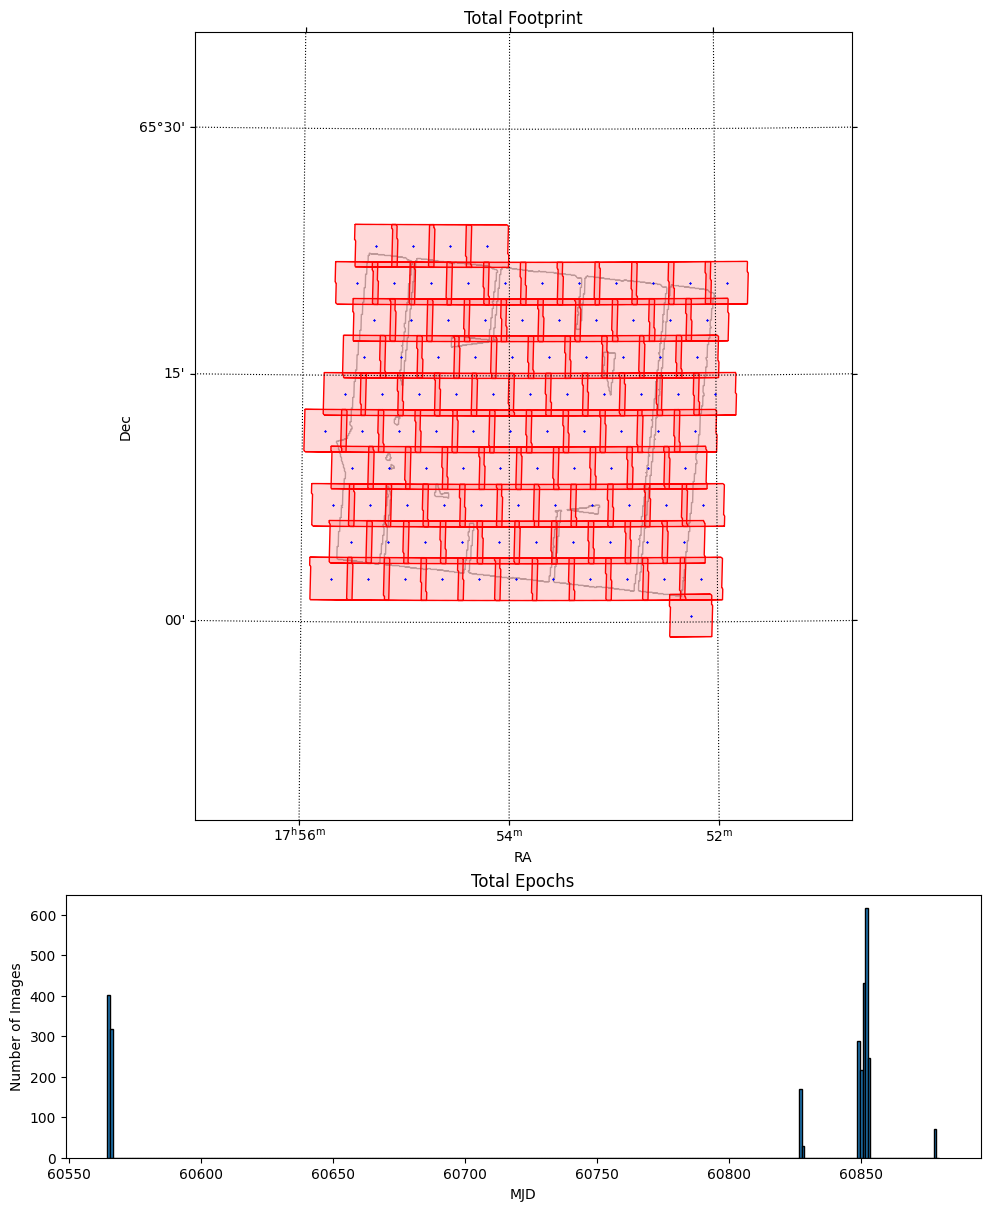

In [52]:
unioned_image_moc = data_utils.DataUtils.Get_Unioned_MOC(lvl2_df.moc)
tile_dataframe = data_utils.DataUtils.GenerateSkyTiles(project_id=project_id,
                                            tile_side_length_arc_min=2.5, 
                                            overlap_in_arc_min=0.25, 
                                            moc_to_tile=unioned_image_moc)

print(len(tile_dataframe))

# all_sky_coords = data_utils.DataUtils.test_sky_tiles()
# print(len(all_sky_coords))



unioned_tile_moc = data_utils.DataUtils.Get_Unioned_MOC(tile_dataframe.moc)

covered_area = unioned_tile_moc.sky_fraction*41253
fov_proxy = 1.75*np.sqrt(covered_area) # add a fudge factor since areas aren't circles...
barycenter = unioned_tile_moc.barycenter()

# print(barycenter)
# 
# nearby = []
# from astropy.coordinates import Angle, SkyCoord
# coords = np.asarray(all_sky_coords)
# dr = np.sqrt( (coords[:,0] - barycenter.ra.degree )**2 + (coords[:,1] - barycenter.dec.degree )**2  )
# coords_use = coords[dr<0.5]
# # 
# # for asc in all_sky_coords:
# #     # c = SkyCoord(asc[0], asc[1], unit=(u.deg, u.deg), frame='icrs')
# #     # 
# #     # if barycenter.separation(c).degree < 1.75:
# #     #     nearby.append(asc)
# #     
# #     if np.abs((asc[0] - barycenter.ra.degree)) < 0.25 and np.abs((asc[1] - barycenter.dec.degree)) < 0.25:
# #         nearby.append(asc)
# #         
# 
#         
# print(len(coords_use))
# 
# 
# 
# # viz = Visualizer("/Users/dcoulter/Code/notebooks/diffpype/images/")
# viz.plot_footprint_and_epochs(moc_list=lvl2_df.moc, 
#                               epoch_list=lvl2_df.mjd_avg, 
#                               footprint_title="Total Footprint", 
#                               hist_title="Total Epochs", 
#                               central_coord=barycenter, 
#                               fov_degrees=fov_proxy, 
#                               tile_df=tile_dataframe)
viz.plot_footprint_and_epochs(moc_list=[unioned_image_moc], 
                              epoch_list=lvl2_df.mjd_avg, 
                              footprint_title="Total Footprint", 
                              hist_title="Total Epochs", 
                              central_coord=barycenter, 
                              fov_degrees=fov_proxy, 
                              tile_df=tile_dataframe)

In [6]:
# tiles_df = data_repo.save_tiles(tile_dataframe, project_name, clobber=True) 
# tiles_df = data_repo.save_tiles(tile_dataframe, project_name)
# pprint(len(tiles_df))

tiles_df = data_repo.retrieve_tiles(project_name)
print(tiles_df['name'].to_string(index=False))

 Tile_1
 Tile_2
 Tile_3
 Tile_4
 Tile_5
 Tile_6
 Tile_7
 Tile_8
 Tile_9
Tile_10
Tile_11
Tile_12
Tile_13
Tile_14
Tile_15
Tile_16
Tile_17
Tile_18


In [7]:
# No safety on this -- it will just duplicate if saved again... can fix with an UPSERT specifying that the combination of lvl2 id and tile id is UNIQUE
# tile_image_dict = data_repo.save_tile_image_association(tiles_df, lvl2_df)

In [8]:
tile_image_dict = data_repo.retrieve_tile_image(project_name, tiles_df, lvl2_df)

tile_ids = tile_image_dict.keys()
tile_names = [tiles_df[tiles_df["id"]==_id].name.iloc[0] for _id in tile_ids]


print("Tile ID, Tile Name, Filter Tuples")
for _id, _name in zip(tile_ids, tile_names):
    band_id_per_tile = tile_image_dict[_id].band_id.to_list()
    _tmp_b = []
    for b in band_id_per_tile:
        _tmp_b.append(b)
    uniq_b = set(_tmp_b)
    b_names = [data_repo.reverse_bands[b] for b in uniq_b]
    print(_id, _name, [(b_id, b_name) for (b_id, b_name) in zip(uniq_b, b_names)])
    
        
# pprint(type(tile_image_dict[128]))


Tile ID, Tile Name, Filter Tuples
1 Tile_1 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (5, 'F277W'), (6, 'F356W'), (7, 'F410M'), (8, 'F444W'), (9, 'F090W')]
2 Tile_2 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (4, 'F212N'), (5, 'F277W'), (6, 'F356W'), (7, 'F410M'), (8, 'F444W'), (9, 'F090W')]
3 Tile_3 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (5, 'F277W'), (6, 'F356W'), (7, 'F410M'), (8, 'F444W'), (9, 'F090W')]
4 Tile_4 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (4, 'F212N'), (5, 'F277W'), (6, 'F356W'), (7, 'F410M'), (8, 'F444W'), (9, 'F090W')]
5 Tile_5 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (4, 'F212N'), (5, 'F277W'), (6, 'F356W'), (7, 'F410M'), (8, 'F444W'), (9, 'F090W')]
6 Tile_6 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (5, 'F277W'), (6, 'F356W'), (7, 'F410M'), (8, 'F444W'), (9, 'F090W')]
7 Tile_7 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (5, 'F277W'), (6, 'F356W'), (7, 'F410M'), (8, 'F444W'), (9, 'F090W')]
8 Tile_8 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (4, 'F212N'), (5, 

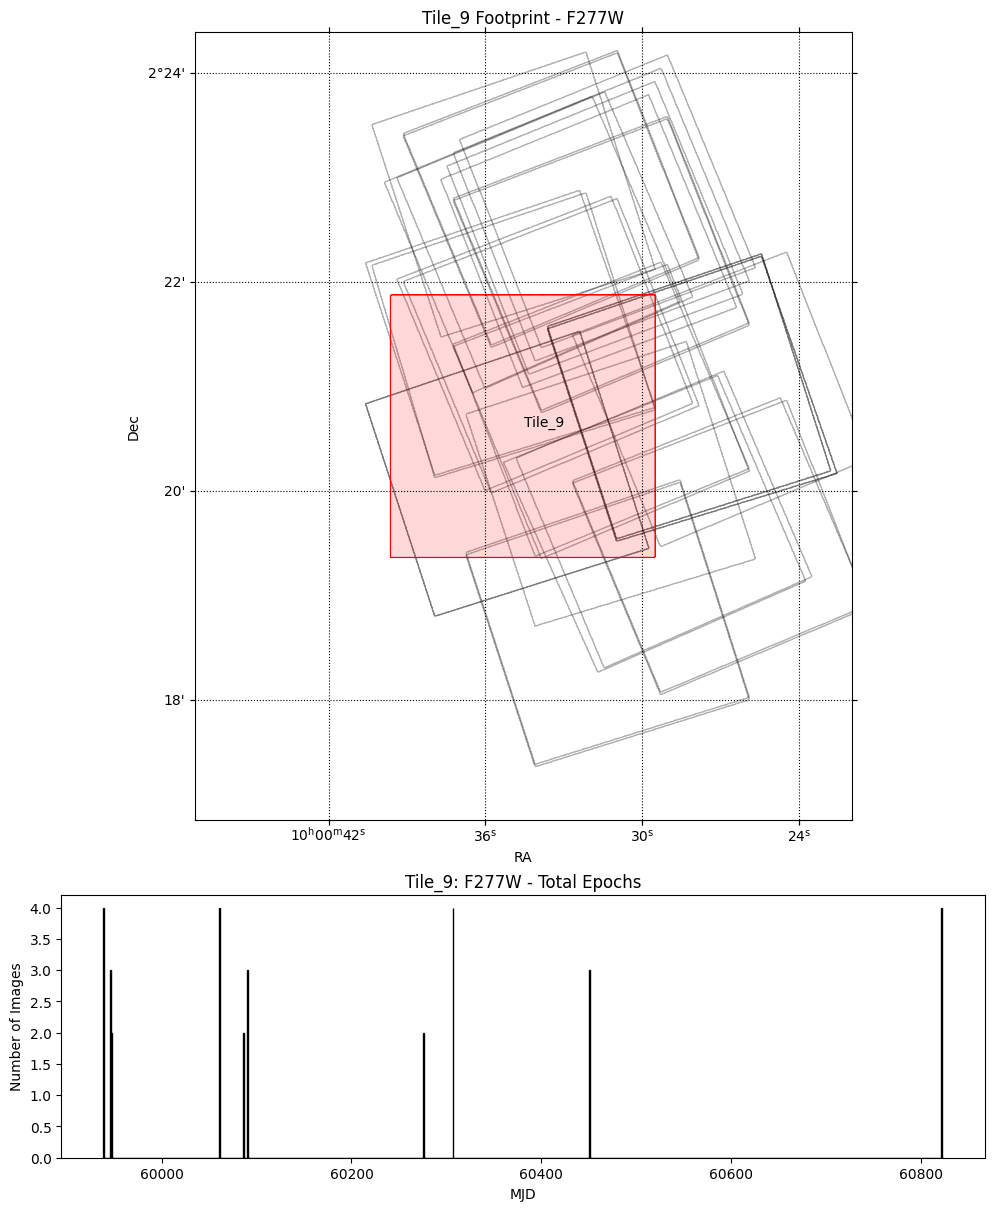

In [9]:
tile_id = 9 # Tile 1
# filter_tups = [(3, 'F200W')]
# filter_tups = [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (8, 'F444W')]
# filter_tups = [(3, 'F200W'), (8, 'F444W')]
# filter_tups = [(8, 'F444W')]
filter_tups = [(5, 'F277W')]
viz.plot_tile_contents(image_dataframe=tile_image_dict[tile_id], tile_dataframe=tiles_df, filter_tuples=filter_tups, tile_id=tile_id, fov_scale=2.5)


In [10]:
do_save = False
distance_thresh = 10

# For tile, for filter -> grab epochs from the resulting image list
for tile_id, images_in_tile in tile_image_dict.items():
    
    for _band_id in images_in_tile["band_id"].unique():        
        
        in_band_images = images_in_tile[images_in_tile["band_id"] == _band_id]
        in_band_mjds = list(in_band_images.mjd_avg)
        epochs = DataUtils.CreateEpochsFromMJDs(in_band_mjds, peak_distance_thresh=distance_thresh)
        
        if do_save:
            data_repo.save_tile_epochs(start_mjds=epochs[:,0], end_mjds=epochs[:,1], tile_id=tile_id, band_id=_band_id, project_id=project_id)

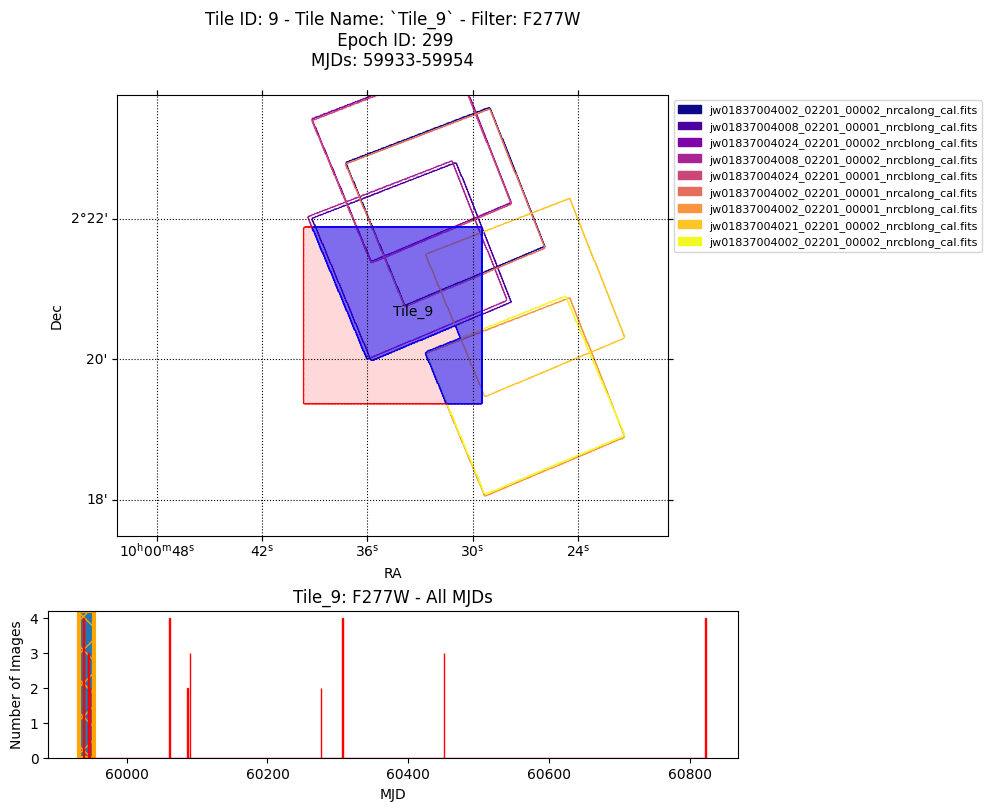

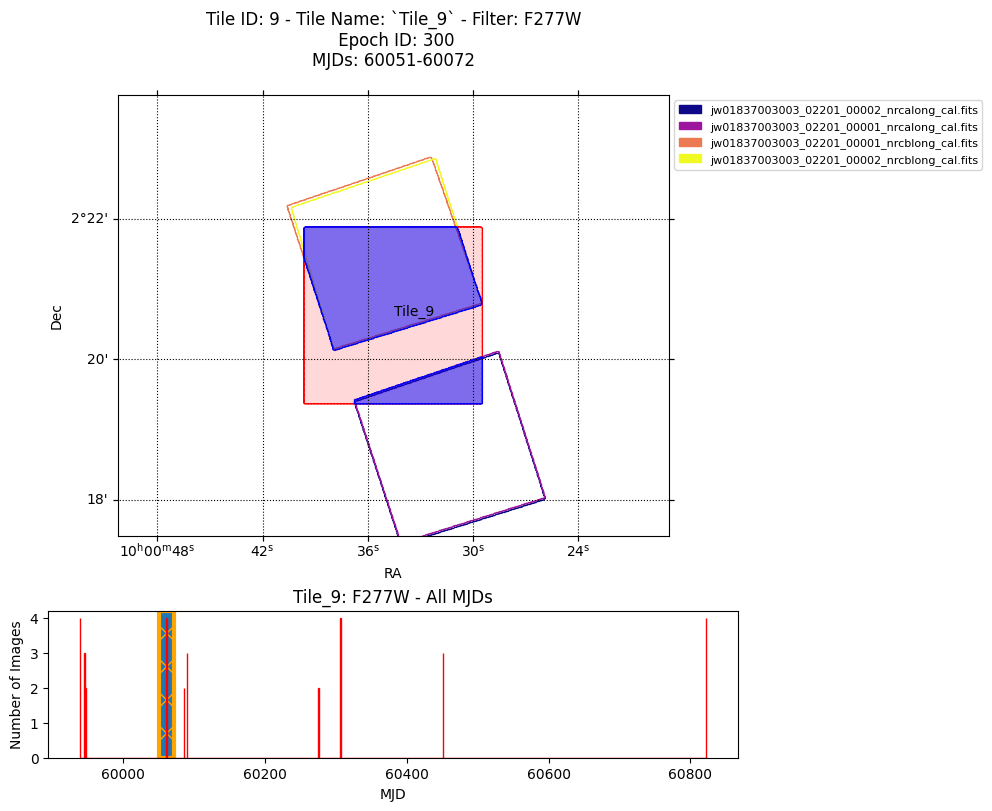

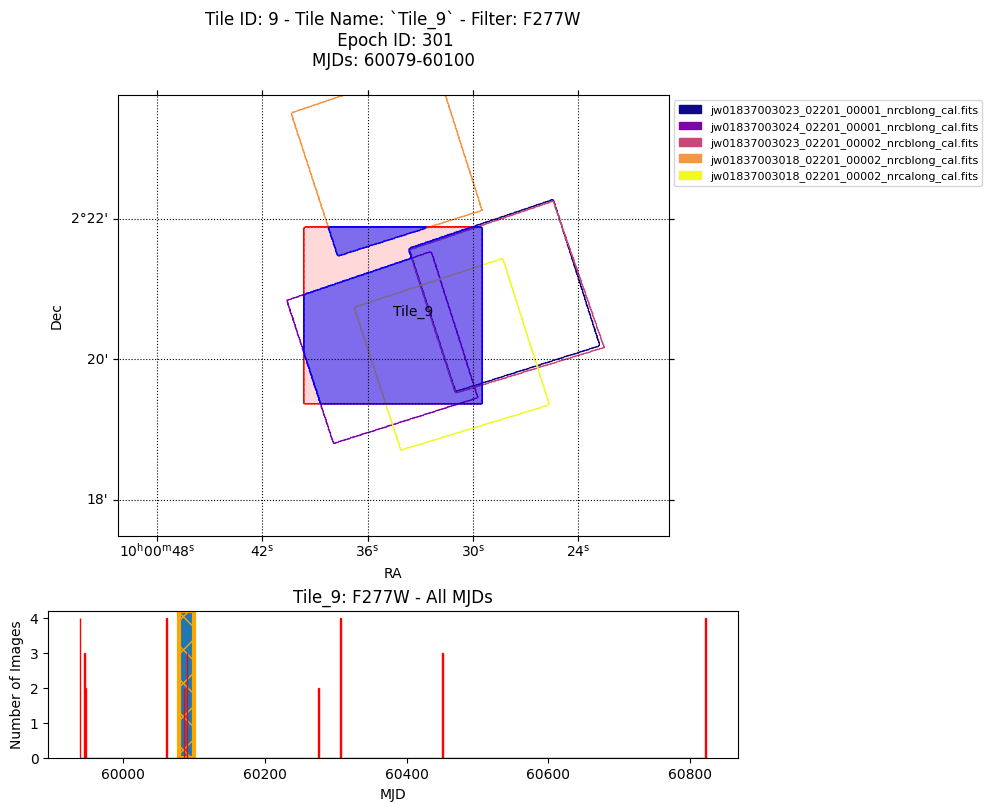

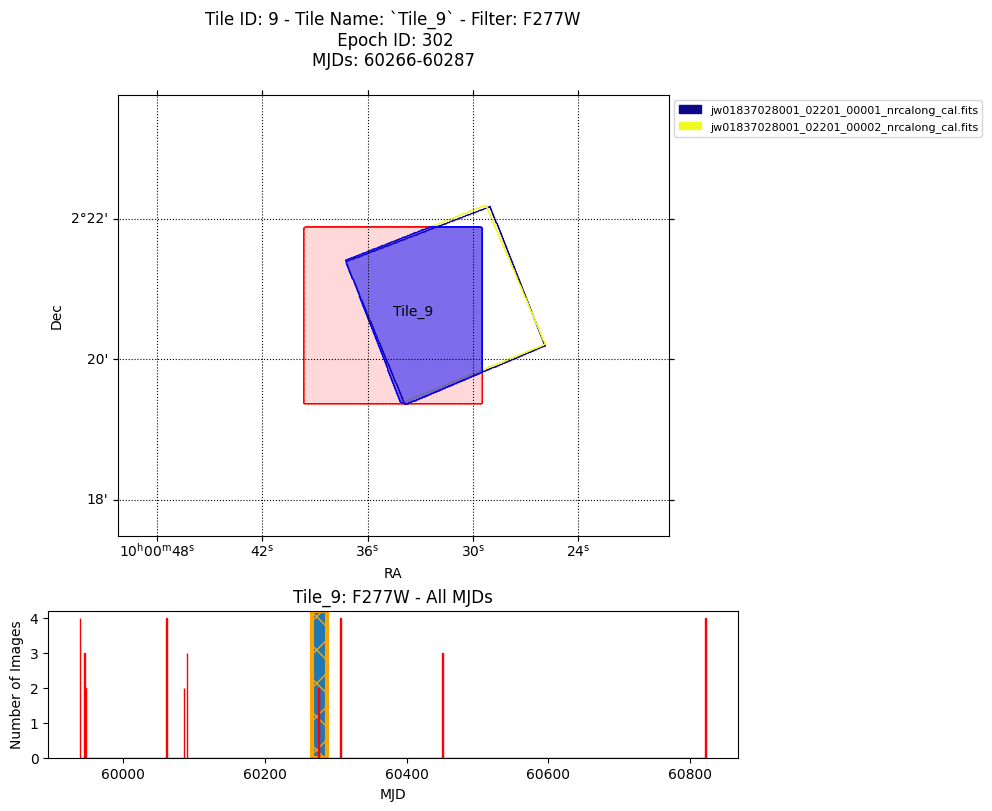

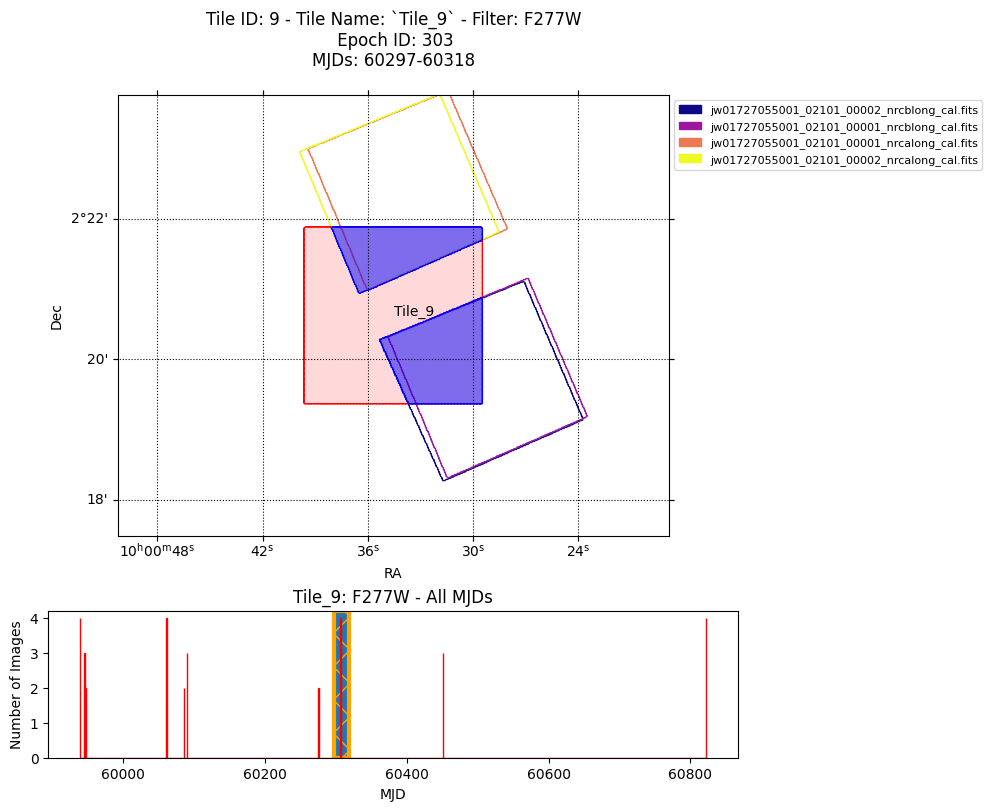

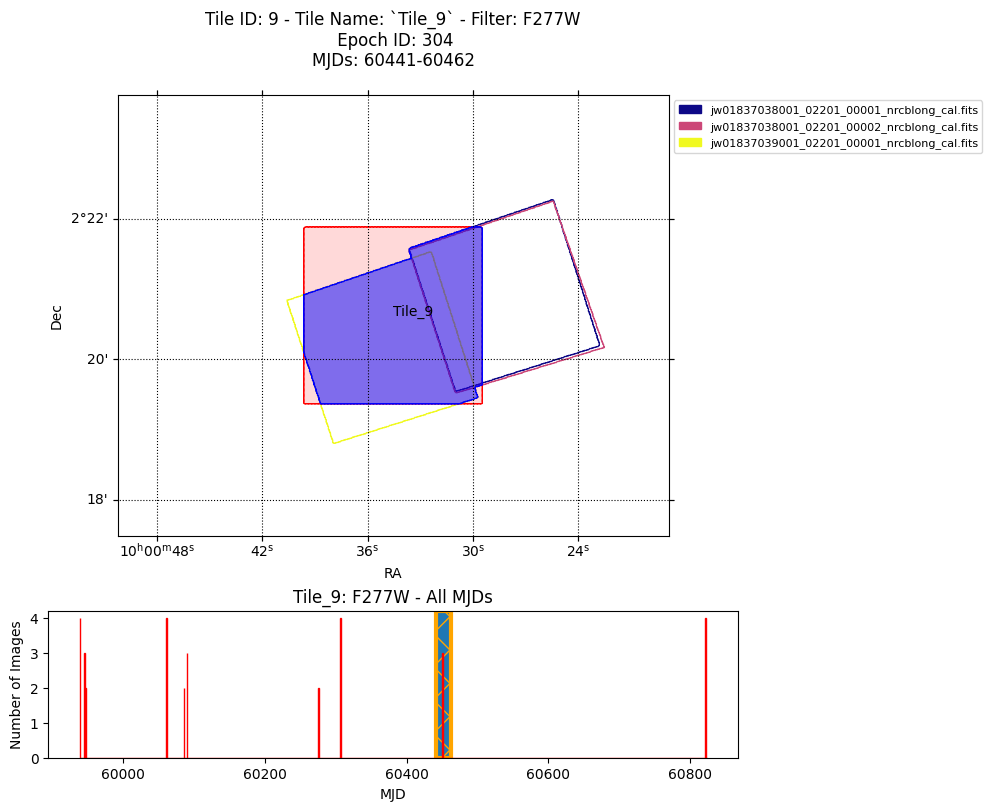

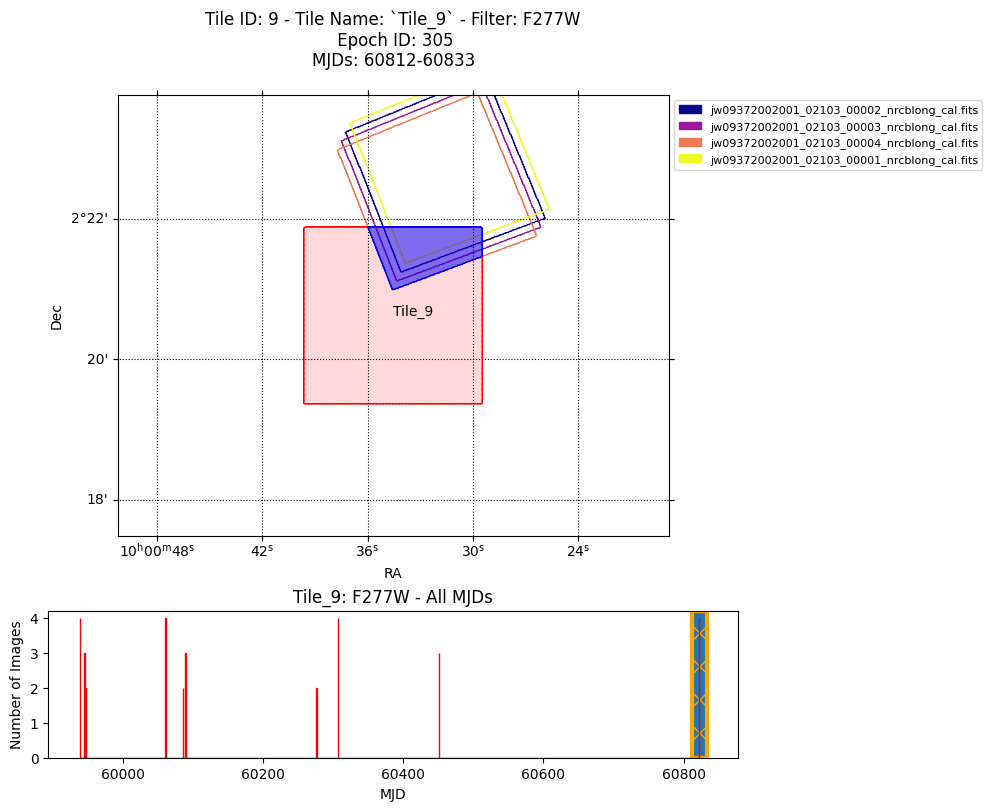

In [11]:
# Plot any combination of tile and band
_tile_id = 9
_tile_filter_tuple = (5, 'F277W')
# _tile_id = 17
# _tile_filter_tuple = (1, 'F115W')

# _tile_filter_tuple = (8, 'F444W')


_tile_df = tiles_df[tiles_df["id"] == _tile_id]
_tile_obj = _tile_df.iloc[0]
_tile_epochs = data_repo.retrieve_tile_epochs(tile_id=_tile_id, band_id=_tile_filter_tuple[0], project_id=project_id)
_tile_img_df = tile_image_dict[_tile_id]

for _tp_index, _tp in _tile_epochs.iterrows(): 
    _ep_start = _tp["start_mjd"]
    _ep_stop = _tp["end_mjd"]
    
    _in_epoch_imgs = _tile_img_df[(_tile_img_df.mjd_avg >= _ep_start) & (_tile_img_df.mjd_avg <= _ep_stop) & (_tile_img_df.band_id == _tile_filter_tuple[0])]
    
    viz.plot_epochs(all_image_dataframe=_tile_img_df, epoch_image_dataframe=_in_epoch_imgs, tile_dataframe=tiles_df, filter_tuple=_tile_filter_tuple, tile_id=_tile_id, fov_scale=2.5, epoch_record=_tp)
    
    # break

In [52]:
# Save tile-epoch-lvl2 => mosaic
# We have to create a lvl3 record, and then use the ID to create the lvl2->lvl3 lookup table to create the mosaic
#   Mosaic = Tile ID, Band ID, Epoch ID  

# Iterate over all tiles
#   Over all unique bands
#       Over all enclosed images by band
#       Group by epoch
#           Save unique combo of tile_id, band_id, image_id, epoch_id
for tile_id, lvl2_in_tile in tile_image_dict.items():
    
    for band_id in lvl2_in_tile["band_id"].unique():
        in_band_tile_epochs = data_repo.retrieve_tile_epochs(tile_id=tile_id, band_id=band_id, project_id=project_id)
        
        for index, epoch in in_band_tile_epochs.iterrows():

            # Create lvl2-epoch records
            start_mjd = epoch["start_mjd"]
            end_mjd = epoch["end_mjd"]
            epoch_id = epoch["id"]
            in_epoch_lvl2 = lvl2_in_tile[(lvl2_in_tile.mjd_avg >= start_mjd) & (lvl2_in_tile.mjd_avg <= end_mjd) & (lvl2_in_tile.band_id == band_id)]
            
            # Save the association
            lvl2_epoch_assc = data_repo.save_epoch_lvl2cal_association(epoch_id, in_epoch_lvl2)
            
            # Create lvl3mosaic obj
            lvl3mosaic = data_repo.save_lvl3mosaic(project_id, tile_id, band_id, epoch_id, in_epoch_lvl2)

Lvl2Cal-Epoch association exists for Epoch ID:1 and Lvl2Cal ID: 22
Lvl2Cal-Epoch association exists for Epoch ID:1 and Lvl2Cal ID: 299
Lvl2Cal-Epoch association exists for Epoch ID:1 and Lvl2Cal ID: 553
Lvl2Cal-Epoch association exists for Epoch ID:1 and Lvl2Cal ID: 717
Lvl2Cal-Epoch association exists for Epoch ID:1 and Lvl2Cal ID: 1001
No unique lvl2-epochs to save!
Lvl3Mosaic exists for Project ID=`1`, Tile ID=`1`, Band ID=`1`, Epoch ID=`1`. You must remove downstream dependencies and this record to re-create.
Lvl2Cal-Epoch association exists for Epoch ID:2 and Lvl2Cal ID: 106
Lvl2Cal-Epoch association exists for Epoch ID:2 and Lvl2Cal ID: 333
Lvl2Cal-Epoch association exists for Epoch ID:2 and Lvl2Cal ID: 689
Lvl2Cal-Epoch association exists for Epoch ID:2 and Lvl2Cal ID: 901
No unique lvl2-epochs to save!
Lvl3Mosaic exists for Project ID=`1`, Tile ID=`1`, Band ID=`1`, Epoch ID=`2`. You must remove downstream dependencies and this record to re-create.
Lvl2Cal-Epoch association exis

# Start with the state that the database is populated

In [3]:
# project_name = 'COSMOS_3D'
project_df = data_repo.retrieve_project(project_name)
image_df = data_repo.retrieve_images()
lvl2_df = data_repo.retrieve_lvl2_cals()
tiles_df = data_repo.retrieve_tiles(project_name)
tile_image_dict = data_repo.retrieve_tile_image(project_name, tiles_df, lvl2_df)
lvl3mosaic_df = data_repo.retrieve_lvl3mosaic_by_project(project_name)


Returning Project: COSMOS_3D
Returning image table from database.
Returning Image JOIN with Lvl2s table from database.
Returning Project: COSMOS_3D
Returning tiles for Project: COSMOS_3D
Returning Project: COSMOS_3D
Returning tile-lvl2 relation for Project: COSMOS_3D
Returning Project: COSMOS_3D
Returning Lvl3Mosaic JOIN with Tile and Epoch from database for Project: `COSMOS_3D`


In [4]:
print(lvl2_df.lvl2cal_status_id)

0       1
1       1
2       1
3       1
4       1
       ..
1019    1
1020    1
1021    1
1022    1
1023    1
Name: lvl2cal_status_id, Length: 1024, dtype: int64


In [5]:
lvl2_df['lvl2cal_status_id'] = 3
lvl2_df['current_file_ext'] = '_1overf.fits'
print(lvl2_df.lvl2cal_status_id)
print(lvl2_df.current_file_ext)
# print(lvl2_df.poly)

0       3
1       3
2       3
3       3
4       3
       ..
1019    3
1020    3
1021    3
1022    3
1023    3
Name: lvl2cal_status_id, Length: 1024, dtype: int64
0       _1overf.fits
1       _1overf.fits
2       _1overf.fits
3       _1overf.fits
4       _1overf.fits
            ...     
1019    _1overf.fits
1020    _1overf.fits
1021    _1overf.fits
1022    _1overf.fits
1023    _1overf.fits
Name: current_file_ext, Length: 1024, dtype: object


In [6]:
test = data_repo.save_lvl2_cals(lvl2_df)

Performing UPSERT of lvl2 cals to the database...
Returning Image JOIN with Lvl2s table from database.
Index(['lvl2cal_id', 'image_id', 'ra', 'decl', 'obs_start', 'exp_time',
       'target_name', 'base_filename', 'current_file_ext', 'mjd_avg', 'poly',
       'plate_scale', 'band_id', 'instrument_id', 'lvl2cal_status_id', 'moc',
       'central_coord'],
      dtype='object')


In [7]:
print(test.current_file_ext)

0       _1overf.fits
1       _1overf.fits
2       _1overf.fits
3       _1overf.fits
4       _1overf.fits
            ...     
1019    _1overf.fits
1020    _1overf.fits
1021    _1overf.fits
1022    _1overf.fits
1023    _1overf.fits
Name: current_file_ext, Length: 1024, dtype: object
